# \[Kaggle\] Holistic Health and Lifestyle Score

SEOYEON CHOI  
2025-11-17

[data](https://www.kaggle.com/datasets/miadul/holistic-health-and-lifestyle-score-dataset)

# Data

-   This synthetic yet realistic dataset evaluates individuals’ overall
    well-being based on multiple physical and lifestyle factors. Each
    row represents a person’s health and lifestyle attributes, scored
    from real-world patterns, to predict an Overall Health Score
    (0–100).
-   Columns

| Column Name       | Description                                                                 | Type    | Example |
|--------------|---------------------------------------------|-------|-------|
| Physical_Activity | Minutes of moderate to vigorous exercise per day (0–120)                    | Numeric | 45      |
| Nutrition_Score   | Diet quality (0–10) based on nutrient density, balance, and variety         | Numeric | 8       |
| Stress_Level      | Self-reported stress (1–10), where 10 = very high stress                    | Numeric | 6       |
| Mindfulness       | Minutes per day spent in meditation, journaling, or mindful activity (0–60) | Numeric | 10      |
| Sleep_Hours       | Average hours of sleep per night (3–10)                                     | Numeric | 7.5     |
| Hydration         | Liters of water consumed per day (0.5–5.0)                                  | Numeric | 2.8     |
| BMI               | Body Mass Index (18–40)                                                     | Numeric | 24.3    |
| Alcohol           | Units of alcohol per week (0–20)                                            | Numeric | 3       |
| Smoking           | Cigarettes per day (0–30)                                                   | Numeric | 5       |

-   Regression → Predict Overall_Health_Score
-   Classification → Create Health_Status label (e.g., “Poor”,
    “Average”, “Good”)
-   Feature Importance → Which lifestyle factor affects health most
-   Dashboard → Build interactive visualizations in Streamlit or Plotly
    Dash

------------------------------------------------------------------------

In [209]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv('../../../delete/holistic_health_lifestyle_dataset.csv')

In [6]:
df.head()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Physical_Activity     10000 non-null  float64
 1   Nutrition_Score       10000 non-null  float64
 2   Stress_Level          10000 non-null  float64
 3   Mindfulness           10000 non-null  float64
 4   Sleep_Hours           10000 non-null  float64
 5   Hydration             10000 non-null  float64
 6   BMI                   10000 non-null  float64
 7   Alcohol               10000 non-null  float64
 8   Smoking               10000 non-null  float64
 9   Overall_Health_Score  10000 non-null  float64
 10  Health_Status         10000 non-null  object 
dtypes: float64(10), object(1)
memory usage: 859.5+ KB

# Regression → Predict Overall_Health_Score

In [10]:
X = df.drop(['Overall_Health_Score','Health_Status'],axis=1)
y = df['Overall_Health_Score']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.4, random_state=1212)

In [14]:
model = LinearRegression()

In [15]:
model.fit(X_train, y_train)

LinearRegression() In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook. On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org. LinearRegression LinearRegression()

In [17]:
y_pred = model.predict(X_test)

In [22]:
y_pred

array([ 54.80081517,  87.5517459 , 106.87897538, ...,  85.6034847 ,
        76.16164305,  43.69768659])

In [24]:
r2 = r2_score(y_test,y_pred)

In [28]:
round(r2,4)

0.9053

In [26]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred))

In [29]:
round(rmse,4)

6.1302

Text(0.5, 1.0, 'Actual vs Predicted (Linear Regression)')

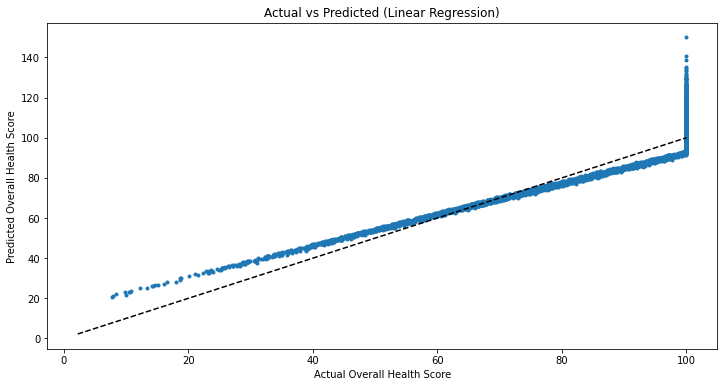

In [51]:
plt.figure(figsize=(12,6))
plt.plot(y_test,y_pred,'.')
plt.plot([y.min(), y.max()],[y.min(), y.max()],'k--')
plt.xlabel('Actual Overall Health Score')
plt.ylabel('Predicted Overall Health Score')
plt.title('Actual vs Predicted (Linear Regression)')

In [56]:
fig = px.scatter(
    x = y_test,
    y=y_pred,
    labels={'x':'Actual Overall Health Score', 'y':'Predicted Overall Health Score'},
    title='Actual vs Predicted (Interaction)',
    width=1000,
    height=600,
    template='seaborn'
)

fig.add_shape(
    type = 'line',
    x0=y.min(), y0=y.min(),
    x1=y.max(), y1=y.max(),
    line=dict(dash='dash')
)

fig

In [63]:
pd.DataFrame({'feature':X.columns,
             'Coefficient':model.coef_})

In [72]:
fig = px.bar(
    pd.DataFrame({'feature':X.columns,
             'Coefficient':model.coef_}).sort_values(by='Coefficient',ascending=False),
    x='feature',
    y='Coefficient',
    title='Feature Importance (Linear Regression Coefficients)',
    width=1200,
    height=500,
    template='seaborn'
)
fig.update_traces(textfont_size=10)
fig

# Classification

In [242]:
df.columns

Index(['Physical_Activity', 'Nutrition_Score', 'Stress_Level', 'Mindfulness',
       'Sleep_Hours', 'Hydration', 'BMI', 'Alcohol', 'Smoking',
       'Overall_Health_Score', 'Health_Status'],
      dtype='object')

In [243]:
feature_cols  = ['Physical_Activity', 'Nutrition_Score', 'Stress_Level', 'Mindfulness',
       'Sleep_Hours', 'Hydration', 'BMI', 'Alcohol', 'Smoking']
target_col = 'Health_Status'

In [244]:
X = df[feature_cols]
y = df[target_col]

In [245]:
X_train, X_test, y_train, y_test = train_test_split(
                                    X, y,
                                    test_size=0.3,
                                    random_state=1212,
                                    stratify=y
                                    )

In [246]:
rf_clf = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 500,
    random_state = 1212
)

In [247]:
rf_clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=500, n_estimators=200, random_state=1212) In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook. On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org. RandomForestClassifier RandomForestClassifier(max_depth=500, n_estimators=200, random_state=1212)

In [248]:
y_pred = rf_clf.predict(X_test)

In [249]:
print(accuracy_score(y_test, y_pred))

0.9016666666666666

In [250]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Average       0.82      0.83      0.83       847
        Good       0.93      0.96      0.95      2028
        Poor       0.96      0.42      0.59       125

    accuracy                           0.90      3000
   macro avg       0.91      0.74      0.79      3000
weighted avg       0.90      0.90      0.90      3000


In [251]:
print(confusion_matrix(y_test, y_pred))

[[ 704  141    2]
 [  80 1948    0]
 [  72    0   53]]

In [252]:
rf_clf.feature_importances_

array([0.05958089, 0.14695664, 0.05456092, 0.39132416, 0.06662972,
       0.0553765 , 0.05974965, 0.06450309, 0.10131843])

In [253]:
sorted(rf_clf.feature_importances_)

[0.054560915836208625,
 0.055376503787369434,
 0.05958089210684196,
 0.05974965275725182,
 0.06450308658146583,
 0.06662971724764624,
 0.10131843171547394,
 0.14695663514721352,
 0.3913241648205286]

In [254]:
df.iloc[y_test.index,:].Health_Status

356        Good
8088       Good
2634       Good
9979    Average
6928    Average
         ...   
6364       Good
5786    Average
7395    Average
4825       Good
3079    Average
Name: Health_Status, Length: 3000, dtype: object

In [255]:
le=LabelEncoder()

In [256]:
y_test_num = le.fit_transform(y_test)

Text(0.5, 1.0, 'Mindfulness and Nutrition Score with Health Status')

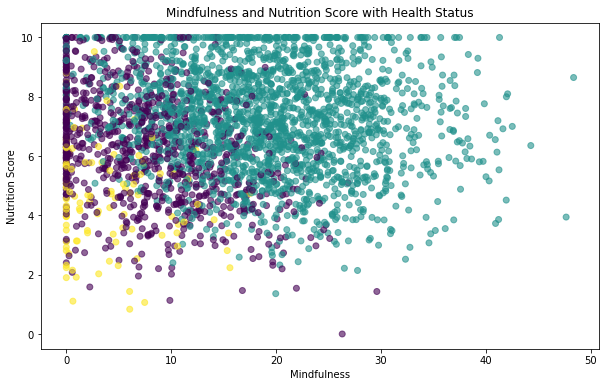

In [257]:
plt.figure(figsize=(10,6))
plt.scatter(X_test.Mindfulness,X_test.Nutrition_Score,c=y_test_num,alpha= 0.6)
plt.xlabel('Mindfulness')
plt.ylabel('Nutrition Score')
plt.title('Mindfulness and Nutrition Score with Health Status')

In [258]:
fig = px.scatter(
    X_test,
        x='Mindfulness',
        y='Nutrition_Score',
        color=y_test,
        opacity=0.6,
        labels={'color': 'Health Status'},
        title='Mindfulness and Nutrition Score with Health Status',
    width=1000,
    height=600,
    template='seaborn'
    )
fig

In [259]:
y_pred_num = le.fit_transform(y_pred)

Text(0.5, 1.0, 'RandomForest Classifiaction for Mindfulness and Nutrition Score with Health Status')

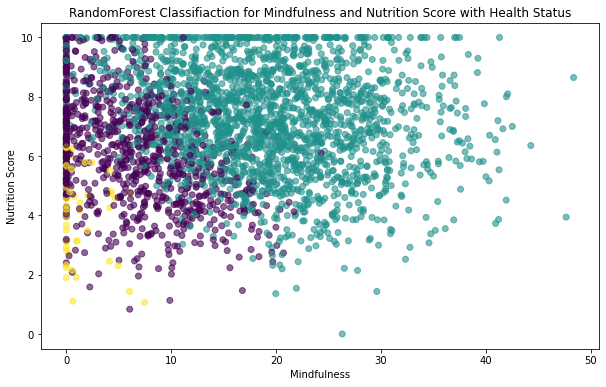

In [260]:
plt.figure(figsize=(10,6))
plt.scatter(X_test.Mindfulness,X_test.Nutrition_Score,c=y_pred_num,alpha= 0.6)
plt.xlabel('Mindfulness')
plt.ylabel('Nutrition Score')
plt.title('RandomForest Classifiaction for Mindfulness and Nutrition Score with Health Status')

In [261]:
fig = px.scatter(
    X_test,
        x='Mindfulness',
        y='Nutrition_Score',
        color=y_pred,
        opacity=0.6,
        labels={'color': 'Predicted Health Status'},
        title='Random Forest for Mindfulness and Nutrition Score with Health Status',
    width=1000,
    height=600,
    template='seaborn'
    )
fig

-   LogisticRegression

In [262]:
log_clf = LogisticRegression(max_iter=1000)

In [263]:
log_clf.fit(X_train, y_train)

/home/csy/anaconda3/envs/temp_csy/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


LogisticRegression(max_iter=1000) In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook. On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org. LogisticRegression LogisticRegression(max_iter=1000)

In [264]:
y_pred = log_clf.predict(X_test)

In [265]:
print(accuracy_score(y_test, y_pred))

0.995

In [266]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Average       1.00      0.99      0.99       847
        Good       1.00      1.00      1.00      2028
        Poor       0.98      0.98      0.98       125

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000


In [267]:
print(confusion_matrix(y_test, y_pred))

[[ 836    9    2]
 [   1 2027    0]
 [   3    0  122]]

In [268]:
sorted(rf_clf.feature_importances_)

[0.054560915836208625,
 0.055376503787369434,
 0.05958089210684196,
 0.05974965275725182,
 0.06450308658146583,
 0.06662971724764624,
 0.10131843171547394,
 0.14695663514721352,
 0.3913241648205286]

In [269]:
y_pred_num = le.fit_transform(y_pred)

Text(0.5, 1.0, 'RandomForest Classifiaction for Mindfulness and Nutrition Score with Health Status')

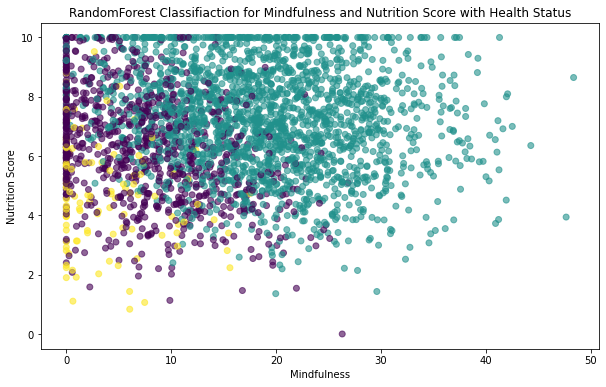

In [270]:
plt.figure(figsize=(10,6))
plt.scatter(X_test.Mindfulness,X_test.Nutrition_Score,c=y_pred_num,alpha= 0.6)
plt.xlabel('Mindfulness')
plt.ylabel('Nutrition Score')
plt.title('RandomForest Classifiaction for Mindfulness and Nutrition Score with Health Status')

In [272]:
fig = px.scatter(
    X_test,
        x='Mindfulness',
        y='Nutrition_Score',
        color=y_pred,
        opacity=0.6,
        labels={'color': 'Predicted Health Status'},
        title='Random Forest for Mindfulness and Nutrition Score with Health Status',
    width=1000,
    height=600,
    template='seaborn'
    )
fig